In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns
from methods import ETL
from prophet import Prophet
from sklearn.metrics import mean_squared_error, r2_score


c:\Users\TobyWong\Desktop\School\EIA Power Prediction\EIA_end_customer_sales_power_prediction_NC\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [2]:
#Set your variables
csv_filename = 'eia_retail_sales_mwh_monthly_state_sectorwide.csv'
path = r'C:\Users\TobyWong\Desktop\School\EIA Power Prediction\EIA_end_customer_sales_power_prediction_NC\data'
stateid = 'NC'
drop_columns = ['ALL', 'OTH', 'RES', 'TRA']
keep_columns = ['COM', 'IND']

In [3]:
df = ETL(
    csv_filename=csv_filename,
    os_path=path,
    stateid=stateid,
    drop_columns=drop_columns,
    keep_columns=keep_columns
)
df.head(1)

,period,stateid,salesUnit,COM_IND
31,2025-11-01,NC,million kilowatt hours,5773.31726


20:28:59 - cmdstanpy - INFO - Chain [1] start processing
20:28:59 - cmdstanpy - INFO - Chain [1] done processing
20:28:59 - cmdstanpy - INFO - Chain [1] start processing
20:29:00 - cmdstanpy - INFO - Chain [1] done processing


Test RMSE: 408.0765095730813
Test R^2: 0.5452615422243765
        period stateid               salesUnit  predicted_COM_IND
299 2025-12-01      NC  million kilowatt hours        5767.827088
300 2026-01-01      NC  million kilowatt hours        6028.693145
301 2026-02-01      NC  million kilowatt hours        5662.009739
302 2026-03-01      NC  million kilowatt hours        5822.219039
303 2026-04-01      NC  million kilowatt hours        5794.954686
304 2026-05-01      NC  million kilowatt hours        6355.658618
305 2026-06-01      NC  million kilowatt hours        6655.442634
306 2026-07-01      NC  million kilowatt hours        7065.533361
307 2026-08-01      NC  million kilowatt hours        7216.496438
308 2026-09-01      NC  million kilowatt hours        6630.302750
309 2026-10-01      NC  million kilowatt hours        6287.483980
310 2026-11-01      NC  million kilowatt hours        5932.582560
311 2026-12-01      NC  million kilowatt hours        5812.888122
312 2027-01-01    

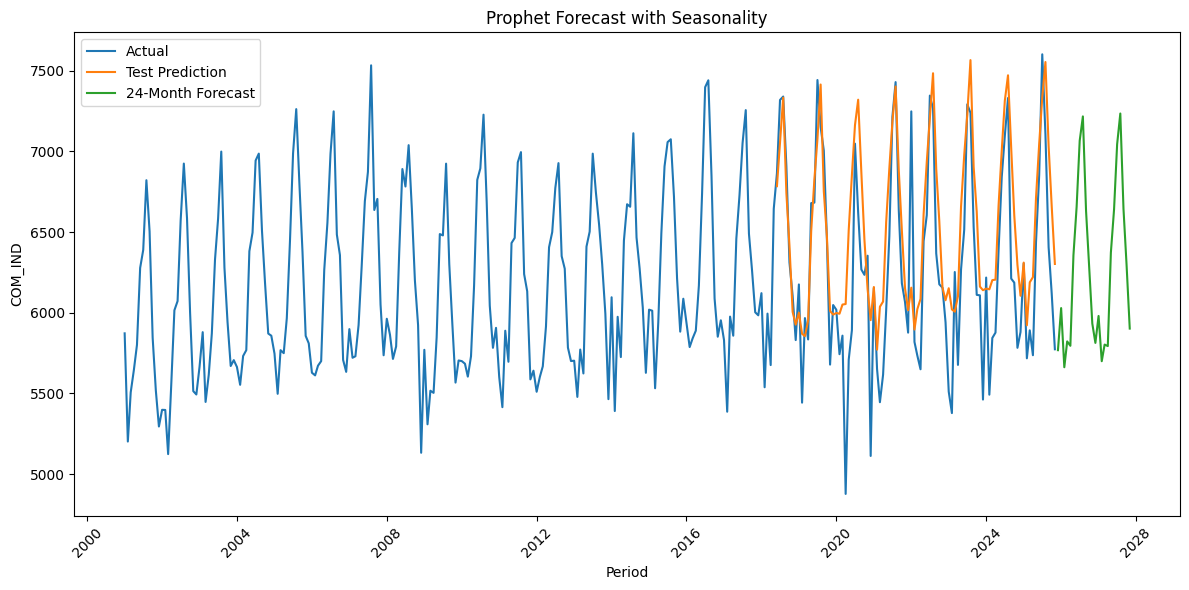

In [ ]:
#version 1
df_model = df.copy()
df_model["period"] = pd.to_datetime(df_model["period"])
df_model = df_model.sort_values("period").reset_index(drop=True)

prophet_df = df_model[["period", "COM_IND"]].rename(columns={"period": "ds", "COM_IND": "y"})

# Train/test split (70/30)
split_idx = int(len(prophet_df) * 0.7)
train = prophet_df.iloc[:split_idx].copy()
test = prophet_df.iloc[split_idx:].copy()

# Fit Prophet model
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode="additive"
)
model.fit(train)

# Predict on test set
test_forecast = model.predict(test[["ds"]])
test["predicted_COM_IND"] = test_forecast["yhat"].values

# Metrics
rmse = np.sqrt(mean_squared_error(test["y"], test["predicted_COM_IND"]))
r2 = r2_score(test["y"], test["predicted_COM_IND"])

print("Test RMSE:", rmse)
print("Test R^2:", r2)

# Refit on full dataset for 24-month forecast
final_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode="additive"
)
final_model.fit(prophet_df)

future = final_model.make_future_dataframe(periods=24, freq="MS")
forecast = final_model.predict(future)

future_forecast = forecast[forecast["ds"] > prophet_df["ds"].max()][["ds", "yhat"]].copy()
future_forecast = future_forecast.rename(columns={"ds": "period", "yhat": "predicted_COM_IND"})
future_forecast["stateid"] = "NC"
future_forecast["salesUnit"] = "million kilowatt hours"

print(future_forecast[["period", "stateid", "salesUnit", "predicted_COM_IND"]])

# Plot
plt.figure(figsize=(12, 6))
plt.plot(prophet_df["ds"], prophet_df["y"], label="Actual")
plt.plot(test["ds"], test["predicted_COM_IND"], label="Test Prediction")
plt.plot(future_forecast["period"], future_forecast["predicted_COM_IND"], label="24-Month Forecast")
plt.xlabel("Period")
plt.ylabel("COM_IND")
plt.title("Prophet Forecast with Seasonality")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

20:34:30 - cmdstanpy - INFO - Chain [1] start processing
20:34:30 - cmdstanpy - INFO - Chain [1] done processing
20:34:30 - cmdstanpy - INFO - Chain [1] start processing
20:34:30 - cmdstanpy - INFO - Chain [1] done processing


Test RMSE: 408.0765095730813
Test R^2: 0.5452615422243765
        period stateid               salesUnit  predicted_COM_IND
299 2025-12-01      NC  million kilowatt hours        5763.416307
300 2026-01-01      NC  million kilowatt hours        6035.400809
301 2026-02-01      NC  million kilowatt hours        5657.718376
302 2026-03-01      NC  million kilowatt hours        5823.665971
303 2026-04-01      NC  million kilowatt hours        5793.300441
304 2026-05-01      NC  million kilowatt hours        6365.949302
305 2026-06-01      NC  million kilowatt hours        6668.050781
306 2026-07-01      NC  million kilowatt hours        7086.363775
307 2026-08-01      NC  million kilowatt hours        7239.164133
308 2026-09-01      NC  million kilowatt hours        6643.542401
309 2026-10-01      NC  million kilowatt hours        6296.711445
310 2026-11-01      NC  million kilowatt hours        5935.506924
311 2026-12-01      NC  million kilowatt hours        5816.568205
312 2027-01-01    

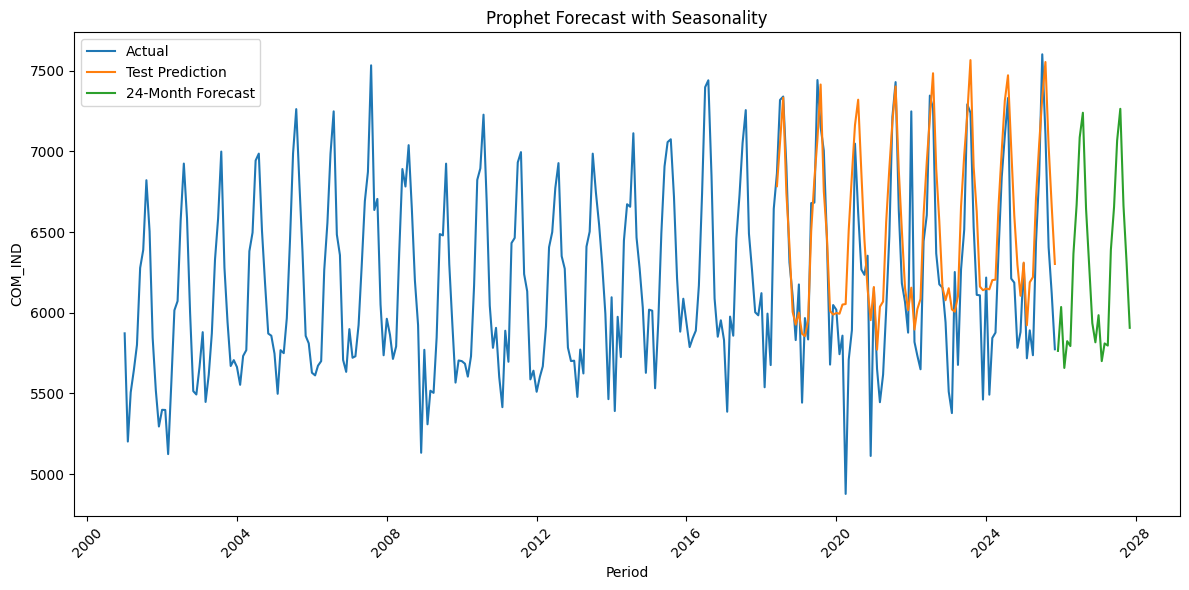

In [5]:
#version 1
df_model = df.copy()
df_model["period"] = pd.to_datetime(df_model["period"])
df_model = df_model.sort_values("period").reset_index(drop=True)

prophet_df = df_model[["period", "COM_IND"]].rename(columns={"period": "ds", "COM_IND": "y"})

# Train/test split (70/30)
split_idx = int(len(prophet_df) * 0.7)
train = prophet_df.iloc[:split_idx].copy()
test = prophet_df.iloc[split_idx:].copy()

# Fit Prophet model
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode="additive"
)
model.fit(train)

# Predict on test set
test_forecast = model.predict(test[["ds"]])
test["predicted_COM_IND"] = test_forecast["yhat"].values

# Metrics
rmse = np.sqrt(mean_squared_error(test["y"], test["predicted_COM_IND"]))
r2 = r2_score(test["y"], test["predicted_COM_IND"])

print("Test RMSE:", rmse)
print("Test R^2:", r2)

# Refit on full dataset for 24-month forecast
final_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode="multiplicative",
    changepoint_prior_scale=0.1,
    seasonality_prior_scale=10.0
)
final_model.fit(prophet_df)

future = final_model.make_future_dataframe(periods=24, freq="MS")
forecast = final_model.predict(future)

future_forecast = forecast[forecast["ds"] > prophet_df["ds"].max()][["ds", "yhat"]].copy()
future_forecast = future_forecast.rename(columns={"ds": "period", "yhat": "predicted_COM_IND"})
future_forecast["stateid"] = "NC"
future_forecast["salesUnit"] = "million kilowatt hours"

print(future_forecast[["period", "stateid", "salesUnit", "predicted_COM_IND"]])

# Plot
plt.figure(figsize=(12, 6))
plt.plot(prophet_df["ds"], prophet_df["y"], label="Actual")
plt.plot(test["ds"], test["predicted_COM_IND"], label="Test Prediction")
plt.plot(future_forecast["period"], future_forecast["predicted_COM_IND"], label="24-Month Forecast")
plt.xlabel("Period")
plt.ylabel("COM_IND")
plt.title("Prophet Forecast with Seasonality")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()